In [3]:
import torch

from transformers import pipeline

In [4]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [4]:
classifier = pipeline("zero-shot-classification", "facebook/bart-large-mnli", device=device)

In [5]:
labels = ["eletronic", "food", "toy", "book"]

In [6]:
predict = classifier("Latest Smartphone with 5G", candidate_labels=labels)

In [7]:
predict

{'sequence': 'Latest Smartphone with 5G',
 'labels': ['eletronic', 'book', 'toy', 'food'],
 'scores': [0.7137377858161926,
  0.11193546652793884,
  0.09917783737182617,
  0.07514885812997818]}

In [1]:
from liqfit.pipeline import ZeroShotClassificationPipeline
from liqfit.models import T5ForZeroShotClassification
from transformers import T5Tokenizer

/Users/matheus/Developer/exploring-hugging-face/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
model = T5ForZeroShotClassification.from_pretrained('knowledgator/comprehend_it-multilingual-t5-base')
tokenizer = T5Tokenizer.from_pretrained('knowledgator/comprehend_it-multilingual-t5-base')
classifier = ZeroShotClassificationPipeline(
    model = model, 
    tokenizer = tokenizer,
    hypothesis_template = '{}', 
    encoder_decoder = True,
    device = device
)

You are using a model of type T5 to instantiate a model of type t5. This is not supported for all configurations of models and can yield errors.


In [6]:
labels = ["beleza", "cozinha", "livros"]

In [7]:
predict = classifier("Esse body splash refrescante e bom para uso", labels, multi_label=False)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [8]:
predict

{'sequence': 'Esse body splash refrescante e bom para uso',
 'labels': ['beleza', 'livros', 'cozinha'],
 'scores': [0.9413631558418274, 0.03310367837548256, 0.025533199310302734]}

In [9]:
import ssl
import pandas as pd

ssl._create_default_https_context = ssl._create_unverified_context

df = pd.read_csv("https://raw.githubusercontent.com/vqrca/hugging_face/refs/heads/main/Dados/descricoes_produtos.csv")

In [10]:
df

,Descrição
0,Liquidificador de alta potência com jarra de v...
1,"Forno Micro-ondas de 20 litros, com menu desco..."
2,Máquina de café espresso com reservatório de á...
3,Torradeira com capacidade para quatro fatias e...
4,"Panela elétrica multifuncional que cozinha, as..."
5,Smartphone com 128GB de armazenamento e câmera...
6,"Smartwatch monitoramento de passos, frequência..."
7,Notebook gamer com placa de vídeo potente e te...
8,"Smartphone com tela super retina XDR de 6,7 po..."
9,Câmera digital com zoom óptico de 20x e vídeos...


In [11]:
labels = [
    "eletrodoméstico",
    "eletrônico",
    "beleza",
    "brinquedo"
]

In [24]:
def classify(text, labels=labels):
    result = classifier(text, labels, multi_label=False)
    label, prob = max(zip(result["labels"], result["scores"]), key=lambda x: x[1])

    return label

In [25]:
classify(df.loc[0, "Descrição"], labels)

'eletrodoméstico'

In [26]:
df.loc[:, "Label"] = df["Descrição"].apply(classify)

In [27]:
df

,Descrição,Label
0,Liquidificador de alta potência com jarra de v...,eletrodoméstico
1,"Forno Micro-ondas de 20 litros, com menu desco...",eletrodoméstico
2,Máquina de café espresso com reservatório de á...,eletrodoméstico
3,Torradeira com capacidade para quatro fatias e...,eletrodoméstico
4,"Panela elétrica multifuncional que cozinha, as...",eletrônico
5,Smartphone com 128GB de armazenamento e câmera...,eletrônico
6,"Smartwatch monitoramento de passos, frequência...",eletrônico
7,Notebook gamer com placa de vídeo potente e te...,eletrônico
8,"Smartphone com tela super retina XDR de 6,7 po...",eletrônico
9,Câmera digital com zoom óptico de 20x e vídeos...,eletrônico


<Axes: ylabel='Label'>

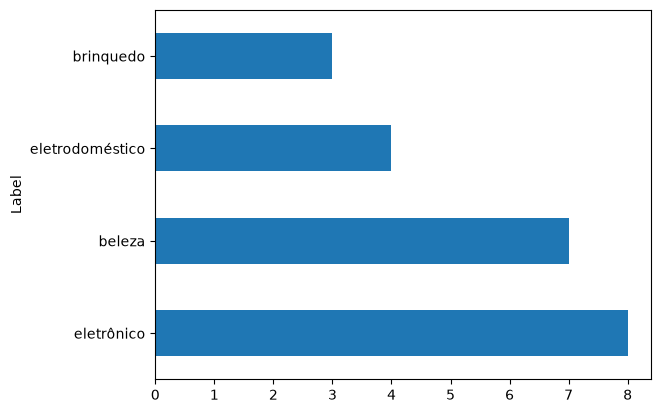

In [33]:
df["Label"].value_counts().plot(kind="barh")